Dataset Shape: (20631, 26)
   unit  time     op1     op2    op3  sensor1  sensor2  sensor3  sensor4  \
0     1     1 -0.0007 -0.0004  100.0   518.67   641.82  1589.70  1400.60   
1     1     2  0.0019 -0.0003  100.0   518.67   642.15  1591.82  1403.14   
2     1     3 -0.0043  0.0003  100.0   518.67   642.35  1587.99  1404.20   
3     1     4  0.0007  0.0000  100.0   518.67   642.35  1582.79  1401.87   
4     1     5 -0.0019 -0.0002  100.0   518.67   642.37  1582.85  1406.22   

   sensor5  ...  sensor12  sensor13  sensor14  sensor15  sensor16  sensor17  \
0    14.62  ...    521.66   2388.02   8138.62    8.4195      0.03       392   
1    14.62  ...    522.28   2388.07   8131.49    8.4318      0.03       392   
2    14.62  ...    522.42   2388.03   8133.23    8.4178      0.03       390   
3    14.62  ...    522.86   2388.08   8133.83    8.3682      0.03       392   
4    14.62  ...    522.19   2388.04   8133.80    8.4294      0.03       393   

   sensor18  sensor19  sensor20  sensor21

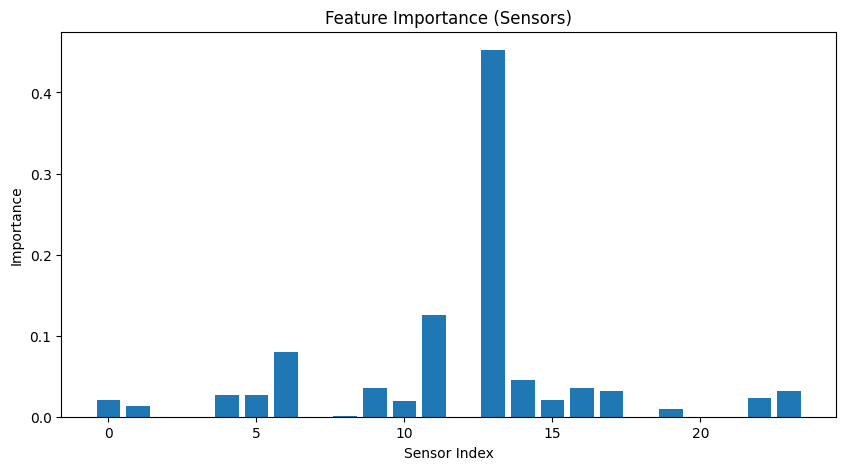


Sample Predictions:
   Actual RUL  Predicted RUL
0         239         148.69
1         238         120.45
2         237         153.39
3         236         151.30
4         235         151.74
5         234         134.12
6         233         155.22
7         232         154.82
8         231         131.78
9         230         132.46


In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("../datasets/turbofan/train_FD001.txt", sep=" ", header=None)

# Remove empty columns
df = df.dropna(axis=1)

# ==============================
# 3. Add Column Names
# ==============================
columns = ['unit', 'time', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1,22)]
df.columns = columns

print("Dataset Loaded:", df.shape)

# ==============================
# 4. Create RUL
# ==============================
df['RUL'] = df.groupby('unit')['time'].transform('max') - df['time']

# 🔥 IMPORTANT: Clip RUL
df['RUL'] = df['RUL'].clip(upper=130)

# ==============================
# 5. Remove Less Useful Columns
# ==============================
df = df.drop(columns=['op1', 'op2', 'op3'])

# ==============================
# 6. Split by Engine (CORRECT WAY)
# ==============================
units = df['unit'].unique()

split = int(len(units) * 0.8)
train_units = units[:split]
test_units = units[split:]

train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]

# ==============================
# 7. Features & Target
# ==============================
X_train = train_df.drop(columns=['unit', 'time', 'RUL'])
y_train = train_df['RUL']

X_test = test_df.drop(columns=['unit', 'time', 'RUL'])
y_test = test_df['RUL']

# ==============================
# 8. Scaling (IMPORTANT)
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 9. Train Model
# ==============================
model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42)
model.fit(X_train, y_train)

# ==============================
# 10. Predictions
# ==============================
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# ==============================
# 11. Evaluation
# ==============================
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("\nModel Performance:")
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

# ==============================
# 12. Feature Importance
# ==============================
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Sensor Index")
plt.ylabel("Importance")
plt.show()

# ==============================
# 13. Sample Predictions
# ==============================
results = pd.DataFrame({
    'Actual RUL': y_test.values[:10],
    'Predicted RUL': test_pred[:10]
})

print("\nSample Predictions:")
print(results)